# ***Model 5: Batch Optimization CNN Model using CIFAR-10 DataSet***

Apply CNN with Batch Normalization, Dropout, and Adam optimizer and evaluate if Batch Normalization will make the training faster or more stable.

In [23]:
%cd /content

import os

if not os.path.exists("/content/cifar10-cnn-classification-project"):
    !git clone https://github.com/karimamzghi/cifar10-cnn-classification-project.git

%cd /content/cifar10-cnn-classification-project

from google.colab import drive
drive.mount("/content/drive")

/content
/content/cifar10-cnn-classification-project
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
MODEL_ID = 5
MODEL_NAME = "batchnorm_cnn"

In [25]:
# Import numpy lib
import importlib

import numpy as np

# Imports matptotlib lib
import matplotlib.pyplot as plt

# Imports tensorflow.Keras lib
import keras as keras
from keras import layers
from keras.backend import clear_session
from keras.optimizers import SGD

# Imports seaborn lib
import seaborn as sns

# Imports sklearn lib
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix

import importlib

from src import config

import src.training.trainer as trainer
import src.training.evaluator as evaluator
import src.data_loader as data_loader

importlib.reload(trainer)
importlib.reload(evaluator)
importlib.reload(data_loader)
importlib.reload(config)

# Imports custom files aka config, experiment files, etc
from src.training.trainer import compile_model, train_model, save_model
from src.training.evaluator import (
    evaluate_model,
    get_predictions,
    calculate_precision_recall,
    save_confusion_matrix
)
from src.data_loader import load_data
from src.experiment_tracker import save_experiment_results    
from src.training.model_builder import build_dropout_cnn, build_batchnorm_cnn

In [26]:
# Load the data fromm cache using the load_data function from data_loader.py
from src.data_loader import load_data

x_train, y_train, x_val, y_val, x_test, y_test = load_data()

Loading cached data from Google Drive: /content/drive/MyDrive/cifar10_cache


In [27]:
# Clear any previous TensorFlow models from memory as TensorFlow can accumulate unnecessary objects in memory,
# especially if we are creating many models while tuning hyperparameters.
clear_session()

In [28]:
# compile the model using the compile_model function from trainer.py
batchnorm_model = build_batchnorm_cnn()
batchnorm_model.summary()

Model: "batchnorm_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,706 (662.91 KB)

 Trainable params: 169,194 (660.91 KB)

 Non-trainable params: 512 (2.00 KB)

In [29]:
# appluy the Adam optimizer to the model using the compile_model function from trainer.py
adam_optimizer = keras.optimizers.Adam(
    learning_rate=config.LEARNING_RATE,
)

batchnorm_model = compile_model(
    model=batchnorm_model,
    optimizer=adam_optimizer,
    loss=config.CATEGORICAL_CROSSENTROPY,
    metrics=[config.ACCURACY]
)

In [30]:
# Train the model using the train_model function from trainer.py
history, train_time = train_model(
    model=batchnorm_model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS
)

Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.4528 - loss: 1.5839 - val_accuracy: 0.5332 - val_loss: 1.2532
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6216 - loss: 1.0805 - val_accuracy: 0.6641 - val_loss: 0.9585
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6786 - loss: 0.9253 - val_accuracy: 0.6816 - val_loss: 0.8940
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7137 - loss: 0.8258 - val_accuracy: 0.7099 - val_loss: 0.8356
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7405 - loss: 0.7529 - val_accuracy: 0.7060 - val_loss: 0.8436
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7625 - loss: 0.6873 - val_accuracy: 0.7449 - val_loss: 0.7433
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7815 - loss: 0.6336 - val_accuracy: 0.7250 - val_loss: 0.7923
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7981 - loss: 0.5899 - val_accuracy: 

In [31]:
# Sanity check: confirm we're using the new 70/15/15 split (15% of 60,000 = 9,000) and not the original Keras default test set (10,000)
print("x_test shape:", x_test.shape)
print("Expected: ~9000 (15% of 60000)")

# Evaluate the baseline model on the held-out test set 
test_loss, test_accuracy = evaluate_model(
    model=batchnorm_model,
    x_test=x_test,
    y_test=y_test
)

test_labels, test_predictions, y_pred_probs = get_predictions(
    model=batchnorm_model,
    x_test=x_test,
    y_test=y_test
)

precision, recall = calculate_precision_recall(
    test_labels=test_labels,
    test_predictions=test_predictions
)

print("Test accuracy:", test_accuracy)
print("Precision:", precision)
print("Recall:", recall)

x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)
x_test shape: (9000, 32, 32, 3)
Expected: ~9000 (15% of 60000)

Test loss: 0.9373868107795715
Test accuracy: 0.7486666440963745
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Precision: 0.7536  Recall: 0.7487
Test accuracy: 0.7486666440963745
Precision: 0.7535827455698464
Recall: 0.7486666666666667


In [32]:
model_path = save_model(
    model=batchnorm_model,
    model_name=f"model_{MODEL_ID}_{MODEL_NAME}",
    models_dir=config.MODELS_DIR
)

Model saved to: ./models/model_5_batchnorm_cnn.keras


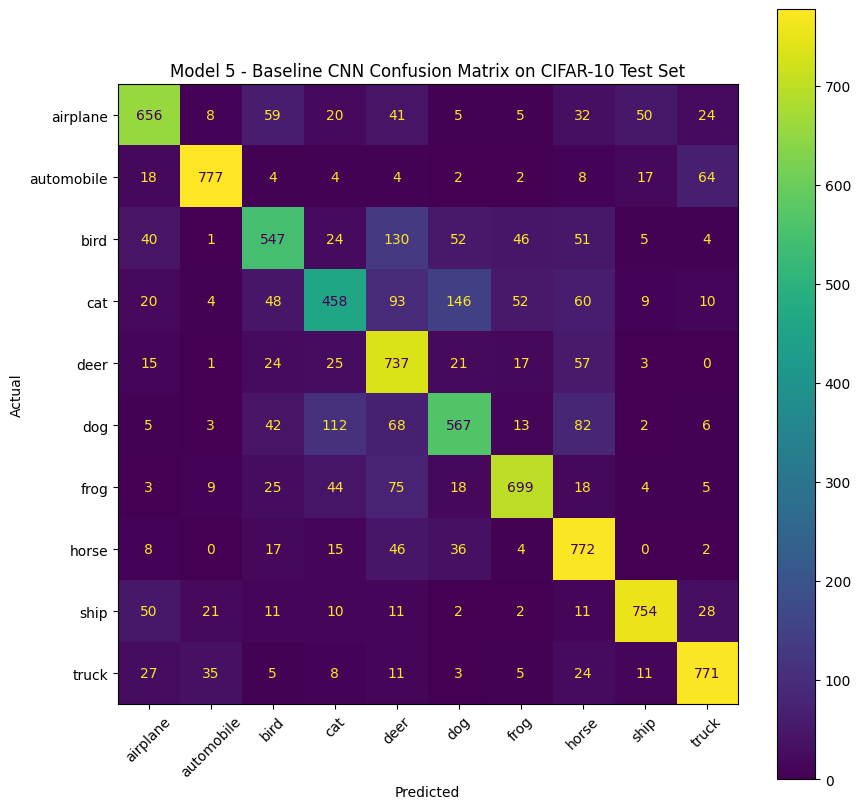

'./results/confusion_matrices/model_5_batchnorm_cnn_confusion_matrix.png'

In [33]:
# Save the confusion matrix to a file
confusion_matrix_path = (
    f"{config.CONFUSION_DIR}/model_{MODEL_ID}_{MODEL_NAME}_confusion_matrix.png"
)

save_confusion_matrix(
    test_labels=test_labels,
    test_predictions=test_predictions,
    output_path=confusion_matrix_path,
    title=f"Model {MODEL_ID} - Baseline CNN Confusion Matrix on CIFAR-10 Test Set"
)

In [34]:
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "architecture": "Conv-Conv-Pool x2 + BatchNorm + Dense(64) + Dropout(0.5)",
    "optimizer": "Adam",
    "learning_rate": config.LEARNING_RATE,
    "batch_size": config.BATCH_SIZE,
    "epochs": len(history.history["accuracy"]),
    "train_accuracy": history.history["accuracy"][-1],
    "validation_accuracy": history.history["val_accuracy"][-1],
    "test_accuracy": test_accuracy,
    "precision": precision,
    "recall": recall,
    "train_loss": history.history["loss"][-1],
    "validation_loss": history.history["val_loss"][-1],
    "test_loss": test_loss,
    "train_time_seconds": train_time,
    "model_path": model_path,
    "confusion_matrix_path": confusion_matrix_path,
    "notes": "Model 5 tests whether Batch Normalization improves stability and performance"}

results_df = save_experiment_results(
    experiment,
    config.RESULTS_PATH
)

results_df

,model_id,model_name,architecture,augmentation,transfer_learning,optimizer,learning_rate,batch_size,epochs,train_accuracy,...,test_accuracy,train_loss,validation_loss,test_loss,model_path,confusion_matrix_path,notes,precision,recall,train_time_seconds
0,1,baseline_cnn,Conv2D(32) + MaxPool + Conv2D(64) + MaxPool + ...,No,No,SGD,0.001,64,20,0.379071,...,0.371000,1.782614,1.779500,1.782990,models/baseline_cnn.keras,results/confusion_matrices/model_1_baseline_cn...,Baseline CNN trained from scratch using SGD op...,NaN,NaN,NaN
1,2,deeper_cnn,Conv2D(32) + Conv2D(32) + MaxPool + Conv2D(64)...,NaN,NaN,SGD,0.001,64,20,0.397976,...,0.323333,1.692275,1.718160,2.002619,./models/model_2_deeper_cnn.keras,./results/confusion_matrices/model_2_deeper_cn...,Model 2 tests whether deeper Conv-Conv-Pool bl...,0.419784,0.323333,80.3
2,3,dropout_cnn,Conv-Conv-Pool x2 + Dense(64) + Dropout(0.5),NaN,NaN,SGD,0.001,64,20,0.274357,...,0.293556,1.979604,1.973125,1.963245,./models/model_3_dropout_cnn.keras,./results/confusion_matrices/model_3_dropout_c...,Model 3 tests whether Dropout reduces overfitt...,0.301318,0.293556,80.8
3,4,adam_optimizer_cnn,Conv-Conv-Pool x2 + Dense(64) + Dropout(0.5),NaN,NaN,Adam,0.001,64,20,0.757143,...,0.734111,0.668025,0.831188,0.797122,./models/model_4_adam_optimizer_cnn.keras,./results/confusion_matrices/model_4_adam_opti...,Model 4 tests optimizer effect by changing fro...,0.737549,0.734111,88.2
4,5,batchnorm_cnn,Conv-Conv-Pool x2 + BatchNorm + Dense(64) + Dr...,NaN,NaN,Adam,0.001,64,20,0.904619,...,0.748667,0.269671,0.963605,0.937387,./models/model_5_batchnorm_cnn.keras,./results/confusion_matrices/model_5_batchnorm...,Model 5 tests whether Batch Normalization impr...,0.753583,0.748667,102.7


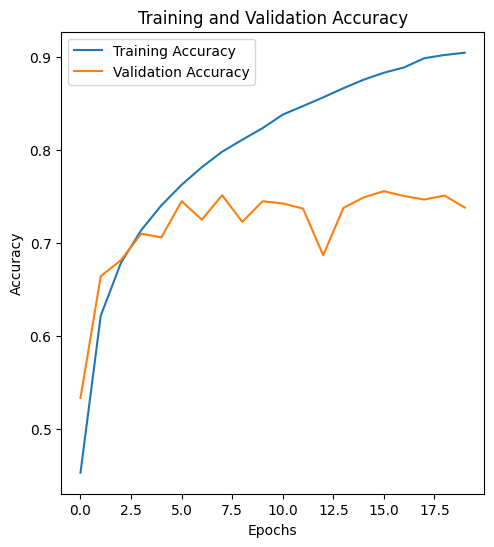

Accuracy curves saved to: ./results/plots/Model_5_batchnorm_cnn_accuracy_curves.png


In [35]:
# draw a plot of the training and validation accuracy over epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Save the plot of the training and validation accuracy over epochs
os.makedirs(config.PLOTS_DIR, exist_ok=True)
accuracy_curves_path = (f"{config.PLOTS_DIR}/Model_{MODEL_ID}_{MODEL_NAME}_accuracy_curves.png")
plt.savefig(accuracy_curves_path, bbox_inches="tight")
plt.show()

print("Accuracy curves saved to:", accuracy_curves_path)

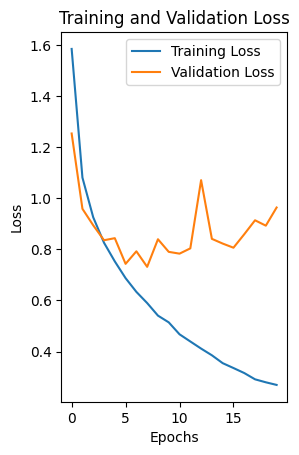

Loss curves saved to: ./results/plots/Model_5_batchnorm_cnn_loss_curves.png


In [36]:
# Draw the training and validation loss over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')    
plt.ylabel('Loss')
plt.legend()

# Save the plot of the training and validation loss over epochs
os.makedirs(config.PLOTS_DIR, exist_ok=True)
loss_curves_path = (f"{config.PLOTS_DIR}/Model_{MODEL_ID}_{MODEL_NAME}_loss_curves.png")
plt.savefig(loss_curves_path, bbox_inches="tight")
plt.show()

print("Loss curves saved to:", loss_curves_path)

In [37]:
# Deploy the model using Gradio interface
%cd /content/cifar10-cnn-classification-project
!PYTHONPATH=/content/cifar10-cnn-classification-project python deployment/app.py

/content/cifar10-cnn-classification-project
Traceback (most recent call last):
  File "/content/cifar10-cnn-classification-project/deployment/app.py", line 12, in <module>
    model = load_trained_model(MODEL_PATH)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/cifar10-cnn-classification-project/src/training/predictor.py", line 9, in load_trained_model
    model = load_model(model_path)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py", line 203, in load_model
    raise ValueError(
ValueError: File not found: filepath=/content/cifar10-cnn-classification-project/models/model_1_baseline_cnn.keras. Please ensure the file is an accessible `.keras` zip file.
